Calculates the performance characteristics of a trapezoidal, 3D wing based on input parameters.

Uses a custom spanwise-loading model for the trapezoidal planform instead of assuming an elliptical lift distribution.

In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Root airfoil=xf-fx63137sm.csv; tip airfoil=xf-fx63137sm.csv; tip washout=0.00 deg
c_r=0.36 m, taper=0.40: alpha=-5° -> CL=0.1617, L/D=10.631, L=12.38 N; alpha=10° -> CL=1.5724, L/D=25.834, L=120.39 N
c_r=0.28 m, taper=0.80: alpha=-5° -> CL=0.1596, L/D=10.487, L=12.22 N; alpha=10° -> CL=1.5514, L/D=24.709, L=118.78 N
c_r=0.25 m, taper=1.00: alpha=-5° -> CL=0.1583, L/D=10.399, L=12.12 N; alpha=10° -> CL=1.5391, L/D=24.011, L=117.84 N
Target lift 70.0 N: c_r=0.36 m, taper=0.40, alpha=3.002 deg, CL=0.9143, CD=0.0313, L/D=29.185
Target lift 70.0 N: c_r=0.28 m, taper=0.80, alpha=3.134 deg, CL=0.9143, CD=0.0324, L/D=28.215
Target lift 70.0 N: c_r=0.25 m, taper=1.00, alpha=3.212 deg, CL=0.9143, CD=0.0331, L/D=27.598


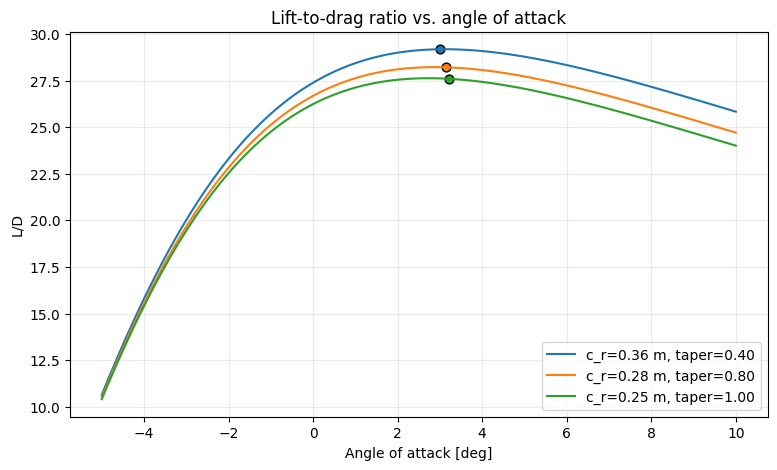

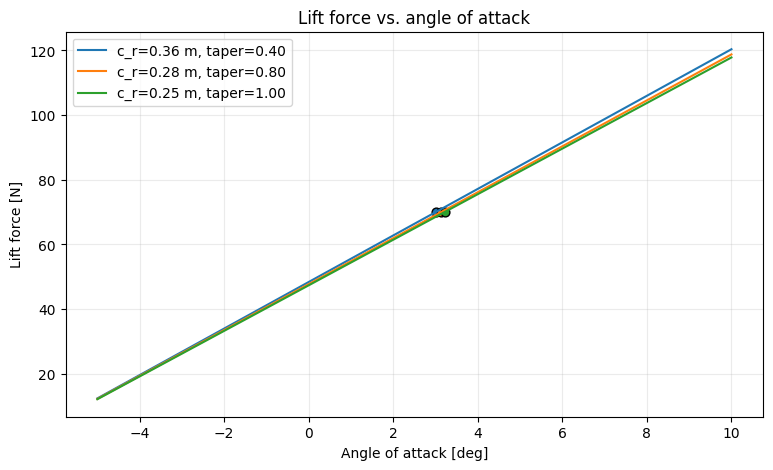

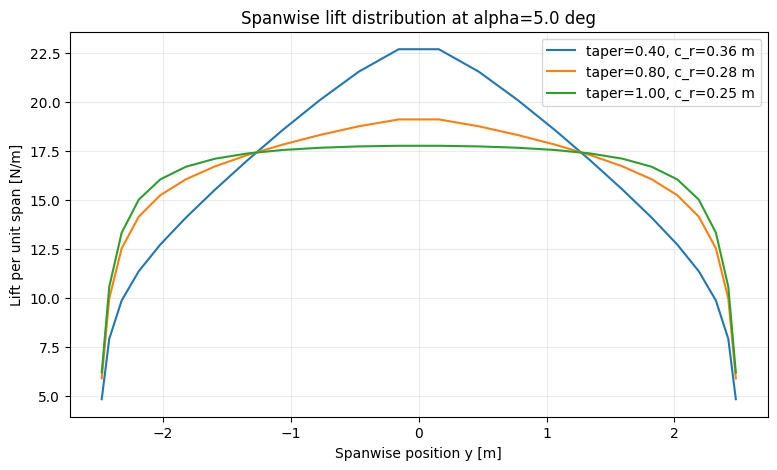

In [49]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import af_2d

# User-selectable taper ratios; root chord is derived to keep area constant.
taper_values = [0.4, 0.8, 1.0]
alpha_vals_deg = np.linspace(-5.0, 10.0, 121)
lift_distribution_alpha_deg = 5.0

# Select polar files at comparable Reynolds and Mach conditions when possible.
airfoil_data_dir_candidates = [
    Path.cwd() / "airfoil-performance",
    Path("airfoil-performance"),
]
airfoil_data_dir = next(
    (path for path in airfoil_data_dir_candidates if path.is_dir()),
    airfoil_data_dir_candidates[0],
)
root_airfoil_name = "xf-fx63137sm.csv"
tip_airfoil_name = "xf-fx63137sm.csv"
root_airfoil_file = airfoil_data_dir / root_airfoil_name
tip_airfoil_file = airfoil_data_dir / tip_airfoil_name
missing_airfoil_files = [
    str(path) for path in (root_airfoil_file, tip_airfoil_file) if not path.exists()
]
if missing_airfoil_files:
    raise FileNotFoundError(f"Airfoil data not found: {', '.join(missing_airfoil_files)}")

tip_washout_deg = 0.0  # Positive values reduce incidence linearly from root to tip.

rho = 1.225  # kg/m^3
V = 10.0     # m/s
b = 5.0      # wingspan, m
wing_area_m2 = 1.25  # Fixed reference area: c_r=0.25 m and taper=1 at this span.
n_modes = 24


def load_airfoil_stats(file_path):
    """Load the 2D polar statistics used by the lifting-line model."""
    return {
        "a0": af_2d.get_C_l_vs_alpha(str(file_path)),
        "alpha_l_0": af_2d.get_alpha_l_0(str(file_path)),
        "cd_0": af_2d.get_C_d_0(str(file_path)),
        "cd_alpha": af_2d.get_C_d_vs_alpha(str(file_path), alpha_min=0.0, alpha_max=5.0),
    }


root_airfoil_stats = load_airfoil_stats(root_airfoil_file)
tip_airfoil_stats = load_airfoil_stats(tip_airfoil_file)


def solve_wing_case(alpha_deg, c_r, lambda_t):
    """Return integrated performance and spanwise lift for one wing case."""
    alpha = np.deg2rad(alpha_deg)
    S = 0.5 * b * c_r * (1.0 + lambda_t)
    AR = b**2 / S

    theta = np.pi * np.arange(1, n_modes + 1) / (n_modes + 1)
    y = -(b / 2.0) * np.cos(theta)
    eta = 2.0 * y / b
    span_fraction = np.abs(eta)
    chord = c_r * (1.0 - (1.0 - lambda_t) * span_fraction)

    a0_span = np.interp(span_fraction, [0.0, 1.0], [root_airfoil_stats["a0"], tip_airfoil_stats["a0"]])
    alpha_l_0_span = np.interp(
        span_fraction, [0.0, 1.0], [root_airfoil_stats["alpha_l_0"], tip_airfoil_stats["alpha_l_0"]]
    )
    cd_0_span = np.interp(
        span_fraction, [0.0, 1.0], [root_airfoil_stats["cd_0"], tip_airfoil_stats["cd_0"]]
    )
    cd_alpha_span = np.interp(
        span_fraction, [0.0, 1.0], [root_airfoil_stats["cd_alpha"], tip_airfoil_stats["cd_alpha"]]
    )
    local_alpha = alpha - np.deg2rad(tip_washout_deg) * span_fraction

    M = np.empty((n_modes, n_modes), dtype=float)
    for j, th in enumerate(theta):
        for n in range(1, n_modes + 1):
            M[j, n - 1] = n * a0_span[j] * np.sin(n * th) / np.sin(th) + (4.0 * b / chord[j]) * np.sin(n * th)

    rhs = a0_span * (local_alpha - alpha_l_0_span)
    A = np.linalg.solve(M, rhs)

    mode_numbers = np.arange(1, n_modes + 1)
    spanwise_load = np.sin(np.outer(mode_numbers, theta)) @ A
    cl_dist = 4.0 * b * spanwise_load / chord

    CL = (1.0 / S) * np.trapezoid(chord * cl_dist, y)
    CD_i = np.pi * AR * np.sum(mode_numbers * A**2)
    cd_profile_span = cd_0_span + cd_alpha_span * (local_alpha - alpha_l_0_span)
    CD_profile = (1.0 / S) * np.trapezoid(chord * cd_profile_span, y)
    CD_total = CD_profile + CD_i
    L_over_D = CL / CD_total

    q = 0.5 * rho * V**2
    lift_per_span = q * chord * cl_dist
    lift_force = q * S * CL
    return {
        "alpha_deg": alpha_deg,
        "CL": CL,
        "CD_total": CD_total,
        "L_over_D": L_over_D,
        "lift_force": lift_force,
        "c_r": c_r,
        "lambda_t": lambda_t,
        "AR": AR,
        "S": S,
        "y_span_m": y,
        "cl_dist": cl_dist,
        "lift_per_span_N_m": lift_per_span,
    }


wing_cases = [
    (2.0 * wing_area_m2 / (b * (1.0 + lambda_t)), lambda_t)
    for lambda_t in taper_values
]

all_cases = []
for c_r, lambda_t in wing_cases:
    curve = []
    for alpha_deg in alpha_vals_deg:
        curve.append(solve_wing_case(alpha_deg, c_r, lambda_t))
    all_cases.append(curve)


def solve_for_target_lift(target_lift_N, c_r, lambda_t, alpha_min=-10.0, alpha_max=25.0):
    """Find the angle of attack that yields a target lift force for a given wing."""
    lo = alpha_min
    hi = alpha_max
    lo_force = solve_wing_case(lo, c_r, lambda_t)["lift_force"]
    hi_force = solve_wing_case(hi, c_r, lambda_t)["lift_force"]
    f_lo = lo_force - target_lift_N
    f_hi = hi_force - target_lift_N

    # Return a marked result if the target is outside the selected angle bracket.
    if f_lo > 0.0 or f_hi < 0.0:
        result = solve_wing_case(alpha_min, c_r, lambda_t)
        result["target_lift_N"] = target_lift_N
        result["alpha_target_deg"] = np.nan
        return result

    for _ in range(200):
        mid = 0.5 * (lo + hi)
        f_mid = solve_wing_case(mid, c_r, lambda_t)["lift_force"] - target_lift_N
        if abs(f_mid) < 1e-6:
            lo = hi = mid
            break
        if f_mid > 0.0:
            hi = mid
        else:
            lo = mid

    alpha_target = 0.5 * (lo + hi)
    result = solve_wing_case(alpha_target, c_r, lambda_t)
    result["target_lift_N"] = target_lift_N
    result["alpha_target_deg"] = alpha_target
    return result


print(f"Root airfoil={root_airfoil_name}; tip airfoil={tip_airfoil_name}; tip washout={tip_washout_deg:.2f} deg")

# Print a quick summary for the first and last operating point in each case.
for case in all_cases:
    first = case[0]
    last = case[-1]
    print(f"c_r={first['c_r']:.2f} m, taper={first['lambda_t']:.2f}: "
          f"alpha=-5° -> CL={first['CL']:.4f}, L/D={first['L_over_D']:.3f}, L={first['lift_force']:.2f} N; "
          f"alpha=10° -> CL={last['CL']:.4f}, L/D={last['L_over_D']:.3f}, L={last['lift_force']:.2f} N")

# Find the efficiency when producing 70 N of lift.
target_lift_N = 70.0
target_results = []
for c_r, lambda_t in wing_cases:
    result = solve_for_target_lift(target_lift_N, c_r, lambda_t)
    if np.isfinite(result["alpha_target_deg"]):
        target_results.append(result)
        print(
            f"Target lift {target_lift_N:.1f} N: c_r={result['c_r']:.2f} m, taper={result['lambda_t']:.2f}, "
            f"alpha={result['alpha_target_deg']:.3f} deg, CL={result['CL']:.4f}, CD={result['CD_total']:.4f}, L/D={result['L_over_D']:.3f}"
        )
    else:
        print(
            f"Target lift {target_lift_N:.1f} N is not reachable in the selected alpha range: "
            f"c_r={result['c_r']:.2f} m, taper={result['lambda_t']:.2f}"
        )

# Plot L/D versus alpha.
fig1, ax1 = plt.subplots(figsize=(9, 5))
for case in all_cases:
    alpha = np.array([item["alpha_deg"] for item in case])
    l_over_d = np.array([item["L_over_D"] for item in case])
    label = f"c_r={case[0]['c_r']:.2f} m, taper={case[0]['lambda_t']:.2f}"
    ax1.plot(alpha, l_over_d, label=label)

for result in target_results:
    ax1.scatter(result["alpha_target_deg"], result["L_over_D"], s=40, marker="o", edgecolors="k")

ax1.set_title("Lift-to-drag ratio vs. angle of attack")
ax1.set_xlabel("Angle of attack [deg]")
ax1.set_ylabel("L/D")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="best")

# Plot lift force versus alpha.
fig2, ax2 = plt.subplots(figsize=(9, 5))
for case in all_cases:
    alpha = np.array([item["alpha_deg"] for item in case])
    lift_force = np.array([item["lift_force"] for item in case])
    label = f"c_r={case[0]['c_r']:.2f} m, taper={case[0]['lambda_t']:.2f}"
    ax2.plot(alpha, lift_force, label=label)

for result in target_results:
    ax2.scatter(result["alpha_target_deg"], result["lift_force"], s=40, marker="o", edgecolors="k")

ax2.set_title("Lift force vs. angle of attack")
ax2.set_xlabel("Angle of attack [deg]")
ax2.set_ylabel("Lift force [N]")
ax2.grid(True, alpha=0.25)
ax2.legend(loc="best")

# Plot lift per unit span at the selected angle of attack.
fig3, ax3 = plt.subplots(figsize=(9, 5))
for c_r, lambda_t in wing_cases:
    distribution = solve_wing_case(lift_distribution_alpha_deg, c_r, lambda_t)
    label = f"taper={lambda_t:.2f}, c_r={c_r:.2f} m"
    ax3.plot(
        distribution["y_span_m"],
        distribution["lift_per_span_N_m"],
        label=label,
    )

ax3.set_title(f"Spanwise lift distribution at alpha={lift_distribution_alpha_deg:.1f} deg")
ax3.set_xlabel("Spanwise position y [m]")
ax3.set_ylabel("Lift per unit span [N/m]")
ax3.grid(True, alpha=0.25)
ax3.legend(loc="best")

plt.show()